## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Becca Hobson

**Date:** 9/30/2026

In [ ]:
# Your Phase 1 solution to the problem goes here.

1. Regression predicts a numerical value while classification predicts a categorical value.
2. A confusion table compares a classification model's predictions against the actual labels from a dataset. This is useful because instead of describing how often a model is right or wrong, it provides the details of how and where the model is making mistakes.
3. The sum of squared errors (SSE) quantifies the difference between the actual values in the data set and the values predicted by the model.
4. Overfitting is the result of a k value that is too small, and results in a model that overfits noise and performs poorly due to excess complexity in the training. Underfitting is the result of a k value that is too large, and resutls in a model that perofrms poorly due to making assumptions and giving too similar of predictions for each dat point.
5. Splittign the data is necessary to ensure the model has actually learned how to predict data, and didn't just memorized every value. Choosing  k  by evaluating accuracy or SSE on the test set improves the model performace signifgantly by optimizing k to avoid both overfitting and underfitting.
6. A class label is simple and easy to interpret because it gives one clear prediction, however, it doesn’t describe how confident the model is. A probability distribution gives more information by showing how likely each class is, but it can be more complicated to interpret and still requires choosing a class if you need one final prediction.

voltage      0
height       0
soil         0
mine_type    0
dtype: int64


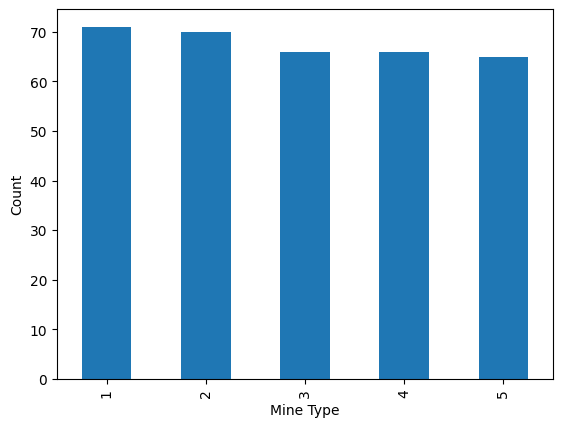

Training set size: 169
Test set size: 169

Training mine types:
mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64

Test mine types:
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64

Optimal k: 1
Validation accuracy: 0.46153846153846156


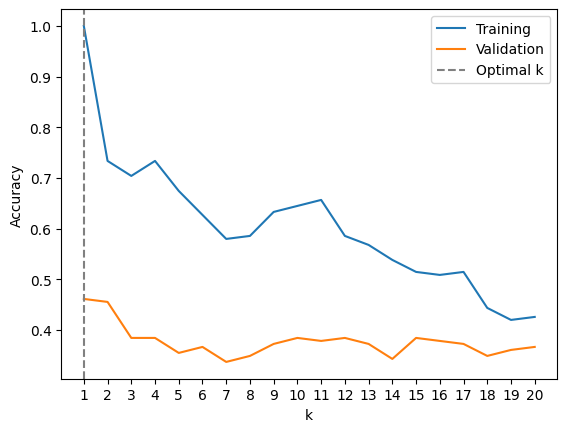

Predicted   1   2  3   4  5
Actual                     
1          21   0  4   4  7
2           0  32  0   3  0
3           8   0  7  10  8
4           7   5  4  11  6
5           7   0  9   9  7

Accuracy: 0.46153846153846156


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

lmdf=pd.read_csv('/content/land_mines.csv')

#EDA
lmdf.sample(20) #inspecting dataset
lmdf.shape #target label: mine_type / features: voltage, height, soil
print(lmdf.isna().sum()) #no missing values present

lmdf['mine_type'].value_counts().sort_index() #realtively balnced distribution
lmdf['mine_type'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Mine Type')
plt.ylabel('Count')
plt.show()

lmdf[['voltage', 'height', 'soil']].describe()

#Split Sample 50/50
X = lmdf[['voltage', 'height', 'soil']] #separate features from target label
y = lmdf['mine_type']

X_train, X_test, y_train, y_test = train_test_split( #split data
    X,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y)

print('Training set size:', len(X_train)) #check size of each set
print('Test set size:', len(X_test))
print('\nTraining mine types:') #check that mine types are represented in both sets
print(y_train.value_counts().sort_index())

print('\nTest mine types:')
print(y_test.value_counts().sort_index())

#kNN classifier
eval_scaler = MinMaxScaler() #scale the training and test data
X_train_scaled = eval_scaler.fit_transform(X_train)
X_test_scaled = eval_scaler.transform(X_test)

eval_ks = np.arange(1, 21) #compare k vlaues 1-20
eval_valid_accuracy = []
eval_train_accuracy = []

for eval_k in eval_ks: #build and fit a separate model for each k using training data
    eval_candidate = KNeighborsClassifier(n_neighbors=int(eval_k))
    eval_candidate.fit(X_train_scaled, y_train)

    eval_valid_hat = eval_candidate.predict(X_test_scaled)
    eval_train_hat = eval_candidate.predict(X_train_scaled)

    eval_valid_accuracy.append(
        np.mean(y_test.to_numpy() == eval_valid_hat))

    eval_train_accuracy.append(
        np.mean(y_train.to_numpy() == eval_train_hat))

eval_k_star = int(eval_ks[np.argmax(eval_valid_accuracy)]) #select best k

print('\nOptimal k:', eval_k_star)
print('Validation accuracy:', max(eval_valid_accuracy))

#compare training vs. validation accuracy to check for overfitting
plt.plot(eval_ks, eval_train_accuracy, label='Training') #plot accuracy for each k
plt.plot(eval_ks, eval_valid_accuracy, label='Validation')
plt.axvline(eval_k_star, linestyle='--', color='gray', label='Optimal k') #label chosen k as optimal
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.xticks(eval_ks)
plt.legend()
plt.show()

#Confusion Tble & Optimal Model
optimal_model = KNeighborsClassifier(n_neighbors=eval_k_star)
optimal_model.fit(X_train_scaled, y_train)
y_pred = optimal_model.predict(X_test_scaled) #predict mine type

confusion_table = pd.crosstab( #create confusion table
    y_test,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted'])
print(confusion_table)

accuracy = np.mean(y_test.to_numpy() == y_pred) #calcualte overall accuracy
print('\nAccuracy:', accuracy)


1. EDA: The dataset has 338 observations with no missing values, and the five mine types are nearly balanced (65–71 each). The target label is mine type and the features are voltage, height, and soil. The three features are all on roughly a 0–1 scale.

2. Split 50/50: I split the data 50/50 so that each mine type appears in both halves in equal numbers (169 observations each). This prevents any class from missing entirely from the training or test set.

3. kNN Classifier: I scaled the features, fit a classifier on the training set for each k from 1 to 20, and compared accuracy on the test set. I selected the k with the highest test accuracy, which was k = 1 (46.2%).

4. Confusion Table: The optimal model is 46.2% accurate overall, well above the 20% expected from guessing among five balanced classes. Type 2 is the easiest to identify, type 1 is moderate, and types 3, 4 and 5 are less accurate and are mostly confused with each other.

5. Model Usage: The model should be used as a tool, not a final identification, since even its overall accuracy is under 50%. A "type 2" prediction can be trusted fairly well, but predictions of types 3, 4 or 5 are right less frequently and often confused, so those should be verified with additional checks.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 4650284
- **AI tool and model used:** ChatGPT

### *Prompts used

1. I'm completing an assignment for my data science class in which I complete phase 1 on my own, and then use an AI model to revise my work. I'm working in colab and github and using python. Here are the instructions for each problem. I have also uploaded the attached data set and the slides from lecture.

Help me understand 1) any mistakes I made/limitations in my work, 2) how to improve/fix them, and 3) why they need to be fixed.

Instructions:

My Code:

Written Components:

2. Provide a concise numbered list of changes.

### *AI-proposed changes



1. Further split training and validation
2. Rename the feature and target variable to match lecture workflow
2. Rename split from "train/test" to "train/validation"
3. Move scaling to immediately after the split and rename the scaled data
4. Include stratification in explanation
5. Update k, accuracy, and confusion table

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / **reject** | checked lecture slides and determined this did not match assignment expectations |
| 2 | **Accept** / modify / reject | matches terminology and improves calrity |
| 3 | **Accept** / modify / reject | accurately describes how the data is used |
| 4 | **Accept** / modify / reject | matches lecture slides |
| 5 | **Accept** / modify / reject | ensures proportional class represnetation in both sets |
| 6 | **Accept** / modify / reject | makes written responses consistent with code |


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


voltage      0
height       0
soil         0
mine_type    0
dtype: int64


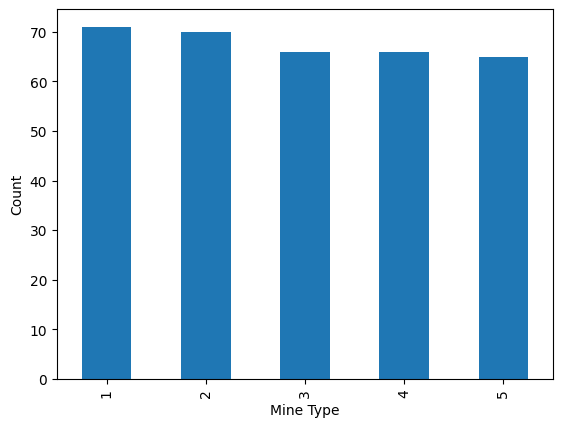

Training set size: 169
Validation set size: 169

Training mine types:
mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64

Validation mine types:
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64

Optimal k: 2
Validation accuracy: 0.4437869822485207


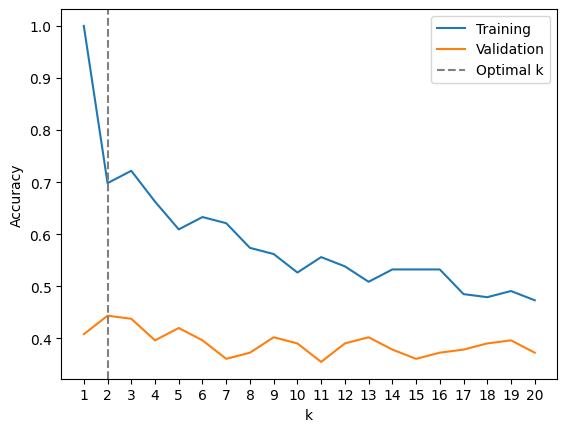

Predicted   1   2   3  4  5
Actual                     
1          25   0   2  3  6
2           0  32   1  2  0
3           9   0  14  5  5
4          19   2   9  2  1
5           7   1  18  4  2

Accuracy: 0.4437869822485207


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

lmdf=pd.read_csv('/content/land_mines.csv')

#EDA
lmdf.sample(20) #inspecting dataset
lmdf.shape #target label: mine_type / features: voltage, height, soil
print(lmdf.isna().sum()) #no missing values present

lmdf['mine_type'].value_counts().sort_index() #realtively balnced distribution
lmdf['mine_type'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Mine Type')
plt.ylabel('Count')
plt.show()

lmdf[['voltage', 'height', 'soil']].describe()

#Split Sample 50/50
eval_X_raw = lmdf[['voltage', 'height', 'soil']] #separate features from target label
eval_y = lmdf['mine_type']
(eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid,
) = train_test_split(
    eval_X_raw,
    eval_y,
    test_size=0.50,
    random_state=72,
    stratify=eval_y)

eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)

print('Training set size:', len(eval_X_train_raw)) #check size of each set
print('Validation set size:', len(eval_X_valid_raw))
print('\nTraining mine types:')
print(eval_y_train.value_counts().sort_index()) #check that mine types are represented in both sets

print('\nValidation mine types:')
print(eval_y_valid.value_counts().sort_index())

#kNN classifier
eval_ks = np.arange(1, 21) #compare k vlaues 1-20
eval_valid_accuracy = []
eval_train_accuracy = []

for eval_k in eval_ks: #build and fit a separate model for each k using training data
    eval_candidate = KNeighborsClassifier(n_neighbors=int(eval_k))
    eval_candidate.fit(eval_X_train_scaled, eval_y_train)

    eval_valid_hat = eval_candidate.predict(eval_X_valid_scaled)
    eval_train_hat = eval_candidate.predict(eval_X_train_scaled)

    eval_valid_accuracy.append(
        np.mean(eval_y_valid.to_numpy() == eval_valid_hat))

    eval_train_accuracy.append(
        np.mean(eval_y_train.to_numpy() == eval_train_hat))

eval_k_star = int(eval_ks[np.argmax(eval_valid_accuracy)]) #select best k

print('\nOptimal k:', eval_k_star)
print('Validation accuracy:', max(eval_valid_accuracy))

#compare training vs. validation accuracy to check for overfitting
plt.plot(eval_ks, eval_train_accuracy, label='Training') #plot accuracy for each k
plt.plot(eval_ks, eval_valid_accuracy, label='Validation')
plt.axvline(eval_k_star, linestyle='--', color='gray', label='Optimal k') #label chosen k as optimal
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.xticks(eval_ks)
plt.legend()
plt.show()

#Confusion Tble & Optimal Model
optimal_model = KNeighborsClassifier(n_neighbors=eval_k_star)
optimal_model.fit(eval_X_train_scaled, eval_y_train)
y_pred = optimal_model.predict(eval_X_valid_scaled) #predict mine type

confusion_table = pd.crosstab( #create confusion table
    eval_y_valid,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted'])
print(confusion_table)

accuracy = np.mean(eval_y_valid.to_numpy() == y_pred) #calcualte overall accuracy
print('\nAccuracy:', accuracy)

EDA: The dataset has 338 observations with no missing values, and the five mine types are nearly balanced (65–71 each). The target label is mine type and the features are voltage, height, and soil. The three features are all on roughly a 0–1 scale.

Split 50/50: I split the data 50/50 so that each mine type appears in both halves in equal numbers (169 observations each and used stratification so that each mine type was proportionally represented in both the training and validation sets. This prevents any class from missing entirely from the training or test set.

kNN Classifier: I scaled the features, fit a classifier on the training set for each \(k\) from 1 to 20, and compared accuracy on the validation set. I selected the \(k\) with the highest validation accuracy, which was \(k=2\) (44.4%).

Confusion Table: The optimal model is 44.4% accurate overall, above the 20% expected from guessing among five nearly balanced classes. Type 2 is the easiest to identify, type 1 is also relatively accurate, and types 3, 4, and 5 are less accurate. Types 4 and 5 are frequently confused with types 1 and 3.

Model Usage: The model should be used as a tool, not a final identification, since its overall accuracy is under 50%. A type 2 prediction is more reliable, but predictions of types 3, 4, and 5 are less reliable and often confused with other types, so those should be verified with additional checks.

### *Reflection on AI assistance
In your own words without generative AI.

The main improvements to my work were reorganizing and renaming variables to more closely follow the workflow used in the lecture slides. I changed the terminology from “training/test” to “training/validation,” moved the scaling step directly after the split, and consistently renamed the raw and scaled datasets. I also used stratification in the 50/50 split to maintain similar proportions of each mine type in both sets. After these changes, I updated my written results to match the final model, which selected \(k=2\) and had a validation accuracy of 44.4%.
One limitation of the AI feedback was that it initially suggested creating an additional training/validation split. After comparing this suggestion with slides from lecture, I determined that this was unnecessary for the expectations of the assignment and decided not to implement the suggested change. This demonstrated the importance of checking AI suggestions against course materials rather than automatically accepting them.
I verified the final solution by comparing each step of my code with the lecture slides, checking the class distributions after splitting, and confirming that the reported accuracy matched the confusion table. One remaining concern is that the model has relatively low overall accuracy and performs much better for some mine types than others, so its predictions should not be treated as definitive identifications.